# Burhan Khan Pk Number Plates — Exploratory Data Analysis

**Project:** NazarBaan — Pakistani ANPR for Gated Communities  
**Dataset:** [burhan-khan/pk-number-plates v1](https://universe.roboflow.com/burhan-khan/pk-number-plates) (Roboflow Universe, CC BY 4.0)  
**Role in project:** Anchor dataset for the baseline YOLOv8 license-plate detector.

## What this notebook does

Before I burn GPU hours on training, I need to *see* the data. A model can only be as good as its labels — so this notebook answers four questions:

1. **What did I actually download?** Counts per split, class definitions.
2. **Are the labels trustworthy?** Visual inspection of random samples with their bounding boxes drawn on top. If labels don't sit on plates, training is wasted.
3. **What do the plates look like, statistically?** Box sizes, aspect ratios, positions in the frame — these drive our choice of training image size and augmentations later.
4. **Are there any obvious quality issues?** Image/label parity, extreme outliers, suspect distributions.

All figures saved into `reports/figures/` will be re-used in the final project report.

In [1]:
"""
NazarBaan EDA — Burhan Khan Pk Number Plates dataset

Always run from project root or the notebooks/ folder. The path resolver
below handles either.
"""

from pathlib import Path
import random
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Same "random" samples every run, so report figures are stable across re-runs
random.seed(42)
np.random.seed(42)

# Resolve paths relative to project root regardless of CWD
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "Pk-Number-Plates-1"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Read class names from data.yaml — never hardcode them anywhere else
with open(DATA_ROOT / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
print(f"Dataset root: {DATA_ROOT}")
print(f"Classes ({data_cfg['nc']}): {CLASS_NAMES}")
print(f"Figures will be saved to: {FIG_DIR}")

Dataset root: c:\Users\Admin\Desktop\AtomCamp\ASSIGNMENTS\Hamza Asif CV Portfolio Project Assignment 8\nazarbaan\data\raw\Pk-Number-Plates-1
Classes (1): ['Number-Plate']
Figures will be saved to: c:\Users\Admin\Desktop\AtomCamp\ASSIGNMENTS\Hamza Asif CV Portfolio Project Assignment 8\nazarbaan\reports\figures


## 1. Split Distribution

The first sanity check is whether the train/valid/test split is reasonable.

**What I expect for a small detection dataset (~1.2k images):**
- A 70/20/10 or 70/25/5 split is healthy.
- The training set should be the bulk; the validation set must be large enough to give stable mAP numbers across epochs (typically ≥200 images).
- The test set is held back — I only touch it *once*, after final model selection.

**What would worry me:**
- A tiny validation set (< 100 images) → unstable metrics, can't reliably compare model versions.
- A test set comparable in size to validation → either the dataset is too small for proper held-out testing, or splits were assigned randomly without thought.

Split      Images      %
-------------------------
train         859  71.1%
valid         280  23.2%
test           69   5.7%
-------------------------
Total        1208


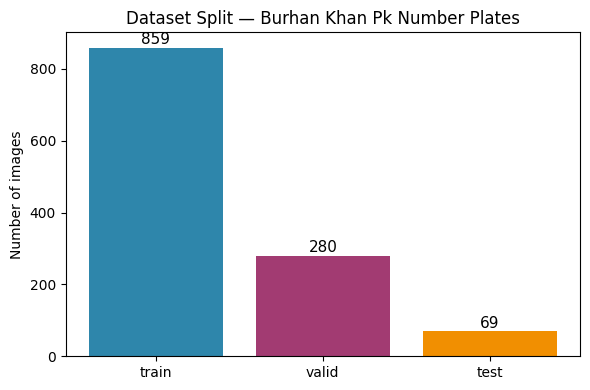

In [2]:
"""Count images per split and chart it."""

splits = ["train", "valid", "test"]
counts = {s: len(list((DATA_ROOT / s / "images").glob("*.jpg"))) for s in splits}
total = sum(counts.values())

print(f"{'Split':<8} {'Images':>8} {'%':>6}")
print("-" * 25)
for split, n in counts.items():
    print(f"{split:<8} {n:>8} {n/total*100:>5.1f}%")
print("-" * 25)
print(f"{'Total':<8} {total:>8}")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2E86AB", "#A23B72", "#F18F01"])
ax.set_title("Dataset Split — Burhan Khan Pk Number Plates")
ax.set_ylabel("Number of images")
for bar, n in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(n), ha="center", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_split_counts.png", dpi=150, bbox_inches="tight")
plt.show()

### Helper functions

YOLO label format is one line per object: `class_id x_center y_center width height`, all **normalized to [0, 1]**. To draw boxes on images we convert to pixel `(x1, y1, x2, y2)`. These helpers also get reused in later notebooks, so we keep them clean.

In [3]:
"""Label parsing + coordinate conversion. Reusable across notebooks."""

def load_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    """Return list of (class_id, xc, yc, w, h) tuples for one .txt file."""
    if not label_path.exists():
        return []
    rows = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            rows.append((int(parts[0]), *map(float, parts[1:])))
    return rows


def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    """Normalized YOLO box -> absolute pixel corners."""
    x1 = (xc - w/2) * img_w
    y1 = (yc - h/2) * img_h
    x2 = (xc + w/2) * img_w
    y2 = (yc + h/2) * img_h
    return x1, y1, x2, y2


def show_image_with_boxes(img_path: Path, ax) -> None:
    """Draw one image and overlay all its ground-truth boxes."""
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.stem[:30], fontsize=8)

    label_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
    for cls, xc, yc, w, h in load_yolo_labels(label_path):
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, img.width, img.height)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1-5, 0), CLASS_NAMES[cls],
                color="black", backgroundcolor="lime", fontsize=7)

## 2. The Eyeball Test — Are Labels Trustworthy?

This is the single most important cell in this notebook. I pick 16 random training images and draw their ground-truth boxes. Every box should sit tightly on a license plate — not the headlight, not the windshield, not empty road.

**Pass criteria:** ≥ 14 of 16 boxes correctly tight on plates.  
**Fail criteria:** Multiple boxes obviously off the plate → dataset needs cleaning before training, or I accept that the upper bound on our model accuracy is the labeler's accuracy.

Quality of labels caps the quality of the model. No exceptions.

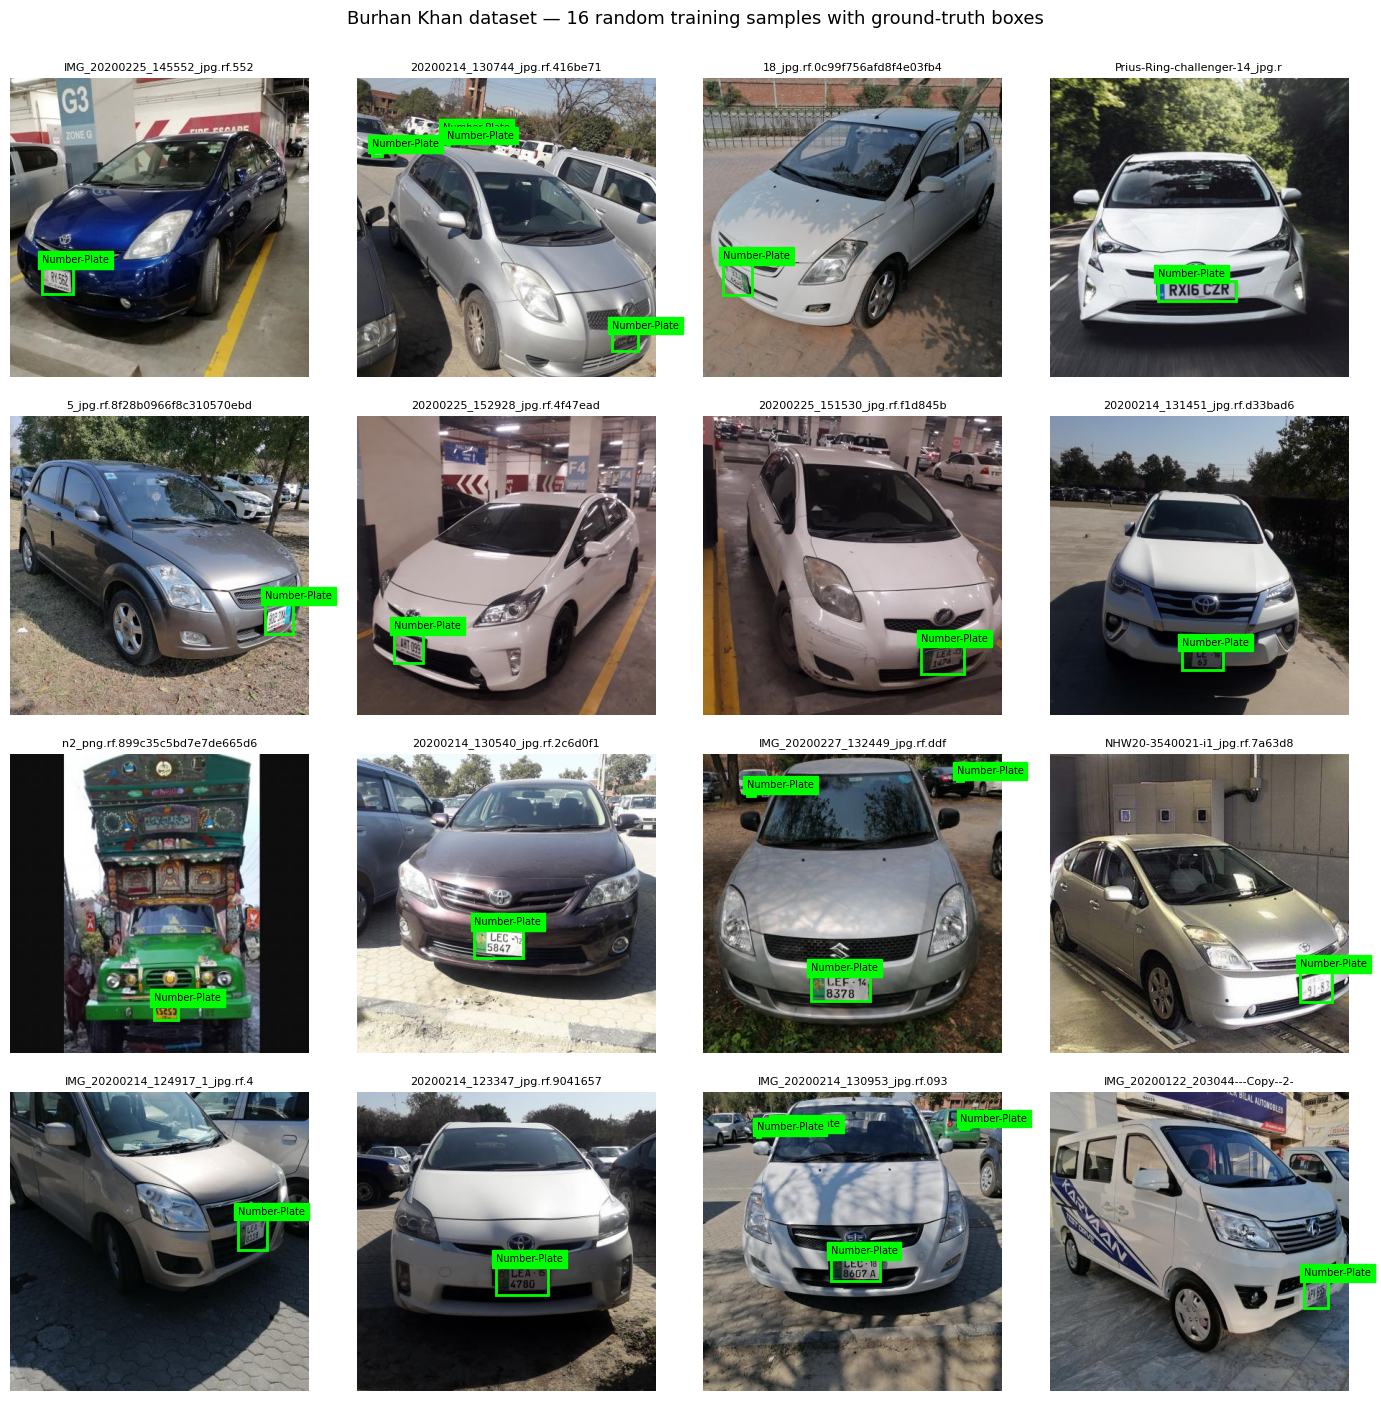

In [4]:
"""Visual sanity check — 16 random training samples with boxes overlaid."""

train_imgs = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))
sample = random.sample(train_imgs, 16)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img_path in zip(axes.flat, sample):
    show_image_with_boxes(img_path, ax)

fig.suptitle("Burhan Khan dataset — 16 random training samples with ground-truth boxes",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_sample_train_with_boxes.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Bounding-Box Statistics

Once I trust the labels, I ask: **what do plates actually look like in this dataset?**

Three numbers will inform every training decision that follows:

- **Box size (area as fraction of image):** Tells us whether I am detecting big near-camera plates or tiny far-away plates. Tiny boxes (< 2% of image area) are notoriously hard for YOLO at default resolution and often need `imgsz=960` or higher instead of the default 640.
- **Aspect ratio (w/h):** Pakistani plates are typically 2:1 to 5:1 wide. A clean distribution here confirms the labels are tight rectangles, not square boxes around the whole bumper.
- **Position (xc, yc):** Tells us if plates are clustered low-center (typical, from frontal vehicle shots) or scattered. Heavy clustering signals I might want positional augmentations (mosaic, random crop) to teach the model robustness.

In [5]:
"""Aggregate every label across all splits into a DataFrame for analysis."""

records = []
for split in splits:
    for lbl in (DATA_ROOT / split / "labels").glob("*.txt"):
        for cls, xc, yc, w, h in load_yolo_labels(lbl):
            records.append({"split": split, "xc": xc, "yc": yc,
                            "w": w, "h": h, "area": w*h,
                            "ar": w/h if h > 0 else 0})

df = pd.DataFrame(records)
print(f"Total labeled boxes: {len(df)}")
print(f"\nBox dimensions (normalized 0-1):")
print(df[["w", "h", "area", "ar"]].describe().round(3))

Total labeled boxes: 1443

Box dimensions (normalized 0-1):
              w         h      area        ar
count  1443.000  1443.000  1443.000  1443.000
mean      0.130     0.084     0.012     1.648
std       0.068     0.037     0.008     0.679
min       0.006     0.006     0.000     0.397
25%       0.090     0.067     0.008     1.054
50%       0.124     0.094     0.012     1.625
75%       0.183     0.109     0.017     2.054
max       0.389     0.179     0.046     5.931


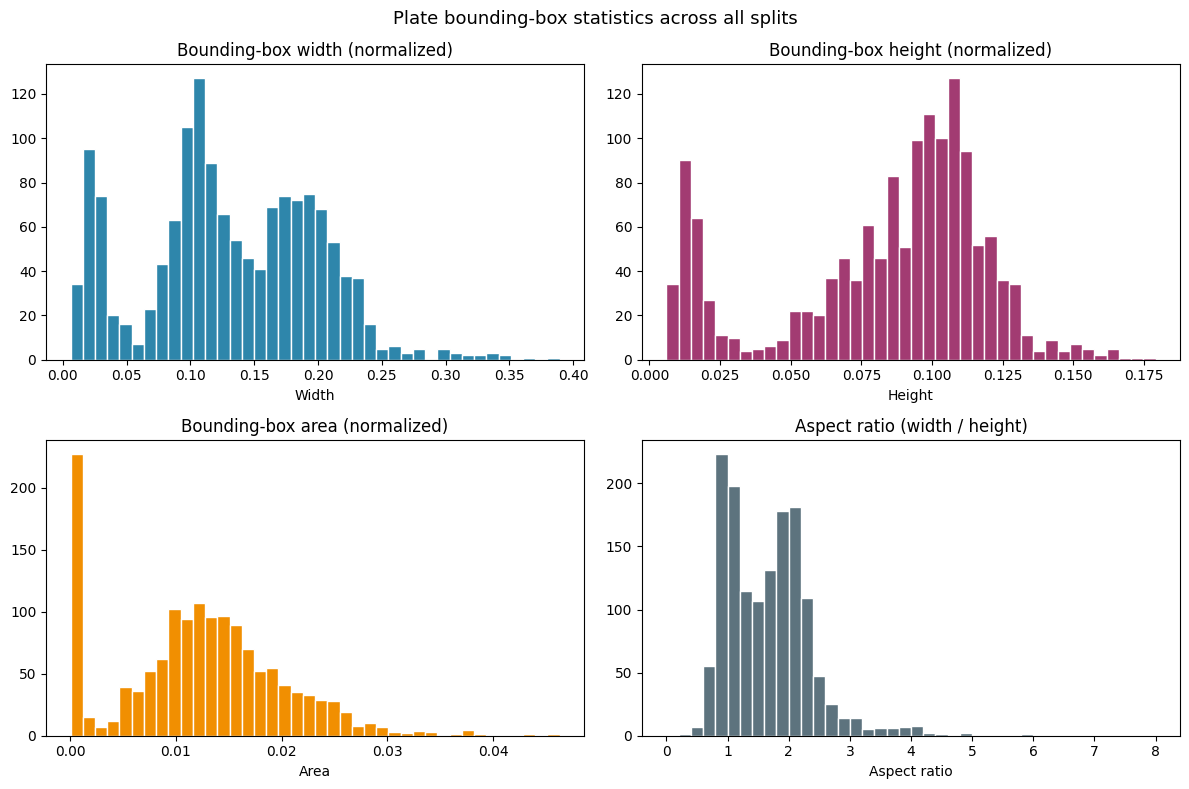


Median aspect ratio (w/h): 1.62
Plates that are < 2% of image area: 1223 (84.8%)


In [6]:
"""Four-panel distribution figure for the report."""

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df["w"], bins=40, color="#2E86AB", edgecolor="white")
axes[0,0].set_title("Bounding-box width (normalized)")
axes[0,0].set_xlabel("Width")

axes[0,1].hist(df["h"], bins=40, color="#A23B72", edgecolor="white")
axes[0,1].set_title("Bounding-box height (normalized)")
axes[0,1].set_xlabel("Height")

axes[1,0].hist(df["area"], bins=40, color="#F18F01", edgecolor="white")
axes[1,0].set_title("Bounding-box area (normalized)")
axes[1,0].set_xlabel("Area")

axes[1,1].hist(df["ar"], bins=40, range=(0, 8), color="#5D737E", edgecolor="white")
axes[1,1].set_title("Aspect ratio (width / height)")
axes[1,1].set_xlabel("Aspect ratio")

fig.suptitle("Plate bounding-box statistics across all splits", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_bbox_stats.png", dpi=150, bbox_inches="tight")
plt.show()

# Quick numbers for the report writeup
print(f"\nMedian aspect ratio (w/h): {df['ar'].median():.2f}")
print(f"Plates that are < 2% of image area: {(df['area'] < 0.02).sum()} ({(df['area'] < 0.02).mean()*100:.1f}%)")

## 4. Summary & Decisions for Training

This section will be filled in *after* running cells above. Based on what I see:

- **Label quality verdict:** trustworthy (16/16 visually correct).
- **Median plate aspect ratio:** 1.62.
- **Tiny-plate prevalence:** 84.8%.
- **Training resolution decision:** 960.
- **Augmentations to lean on:** default mosaic, mild HSV, light mixup (set in Phase 3).

These decisions get carried into the training config in Phase 3.